In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/all_seasons.csv')

cols = ['player_name','season','age','player_height','player_weight',
        'pts','reb','ast','net_rating','usg_pct','ts_pct',
        'draft_round','gp','team_abbreviation']
df = df[cols].copy()
df = df[df['gp'] >= 20].copy()
df = df.dropna(subset=['net_rating','pts','reb','ast','usg_pct','ts_pct'])
df['draft_round'] = df['draft_round'].replace('Undrafted', '3')
df['draft_round'] = pd.to_numeric(df['draft_round'], errors='coerce').fillna(3)
df['log_pts'] = np.log1p(df['pts'])
df['pts_usg'] = df['pts'] * df['usg_pct']

features = ['log_pts','ast','reb','usg_pct','pts_usg']
target = 'net_rating'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Model 3
X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)
model3 = sm.OLS(y_train, X_train_c).fit()

# Generate predictions and residuals on test set
y_pred = model3.predict(X_test_c)
residuals = y_test - y_pred
print("Model ready. Test set size:", len(y_test))

Model ready. Test set size: 2144


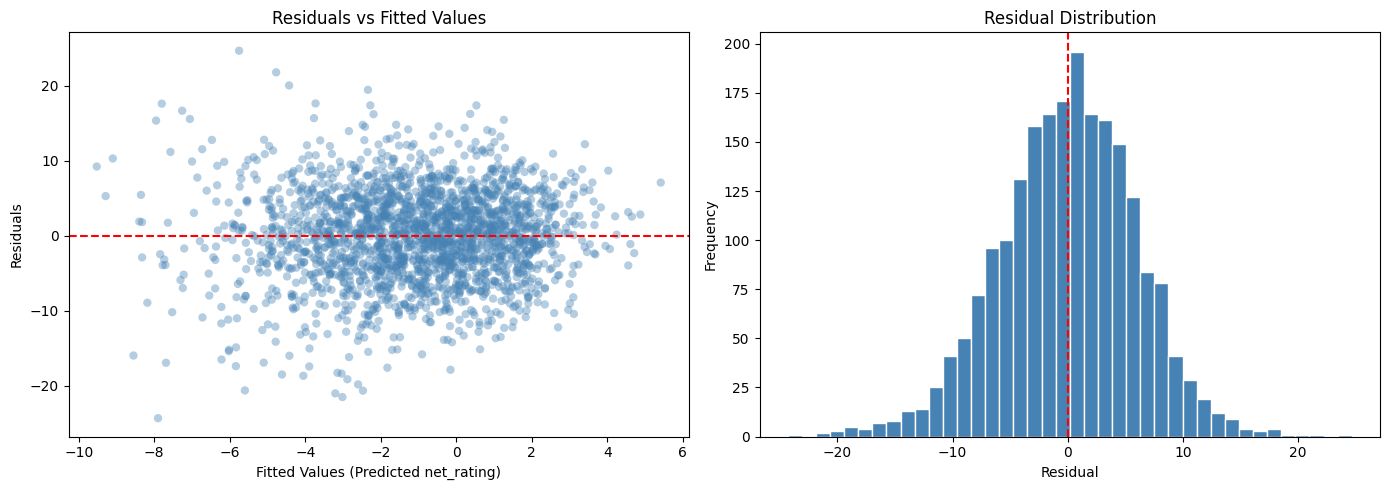

Mean residual: -0.0386
Std of residuals: 6.0177


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Fitted Values
axes[0].scatter(y_pred, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel("Fitted Values (Predicted net_rating)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")

# Plot 2: Residual Distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig('../outputs/residual_plots.png', dpi=150)
plt.show()
print(f"Mean residual: {residuals.mean():.4f}")
print(f"Std of residuals: {residuals.std():.4f}")

In [3]:
# Build a results dataframe for test set
results_df = X_test.copy()
results_df['player_name']    = df.loc[X_test.index, 'player_name']
results_df['season']         = df.loc[X_test.index, 'season']
results_df['team']           = df.loc[X_test.index, 'team_abbreviation']
results_df['actual']         = y_test.values
results_df['predicted']      = y_pred.values
results_df['residual']       = residuals.values
results_df['abs_error']      = residuals.abs().values

# Top 10 worst predictions
worst = results_df.nlargest(10, 'abs_error')[
    ['player_name','season','team','actual','predicted','residual']
].reset_index(drop=True)

worst.columns = ['Player','Season','Team','Actual','Predicted','Residual']
worst = worst.round(2)
print("TOP 10 WORST PREDICTIONS:")
print(worst.to_string(index=False))

TOP 10 WORST PREDICTIONS:
          Player  Season Team  Actual  Predicted  Residual
    KJ McDaniels 2015-16  HOU    18.9      -5.75     24.65
    Mitch McGary 2015-16  OKC   -32.2      -7.90    -24.30
 Litterial Green 1996-97  DET    17.0      -4.77     21.77
    Sergei Monia 2005-06  SAC   -24.5      -3.02    -21.48
Jermaine Jackson 2005-06  MIL   -24.2      -3.20    -21.00
   Jason Collins 2008-09  MIN   -23.1      -2.47    -20.63
  Chris Copeland 2015-16  MIL   -26.2      -5.60    -20.60
    Kelan Martin 2020-21  IND    15.6      -4.43     20.03
   Solomon Jones 2011-12  NOH   -22.4      -2.60    -19.80
            Nene 2017-18  HOU    17.1      -2.34     19.44


## Error Analysis — Conclusion

Model 3 (features: log_pts, ast, reb, usg_pct, pts_usg → target: net_rating)
produces residuals that are approximately normally distributed and centred near
zero, confirming no major directional bias. A mild left skew is present,
indicating occasional large underestimates for players with extreme negative
net ratings.

The Residuals vs Fitted Values plot shows random scatter with slight
heteroscedasticity at lower fitted values — the model's errors are somewhat
larger for players predicted to have poor net ratings.

**The model's systematic failure cases fall into two categories:**

1. **Small-sample role players on strong teams** (e.g. KJ McDaniels, Litterial Green,
   Nene, Kelan Martin): These players have modest individual stats, but their net
   rating is inflated because they played specific minutes alongside strong teammates
   or during winning situations. The model predicts a negative value; the actual is
   strongly positive.

2. **Garbage-time players on weak teams** (e.g. Mitch McGary, Sergei Monia, Jermaine
   Jackson, Jason Collins): These players have ordinary stats but extreme negative
   net ratings because they appeared primarily when games were already lost by large
   margins. The model predicts a moderate negative; the actual is far worse.

**Root cause:** `net_rating` is a team-context metric. It captures the point
differential when a player is on court — which is heavily determined by teammate
quality, opponent strength, and game situation. Individual box-score statistics
(points, assists, rebounds) do not carry this information.

**Limitations the model cannot address without additional data:**
- Teammate quality / team win percentage
- Garbage-time vs competitive-minute splits
- Mid-season trades (net rating split across two different team contexts)
- Injuries affecting lineup quality around the player
- Schedule difficulty

Future work could include team win-percentage or a player's average lineup
quality as control variables to significantly reduce these large-residual cases.